
# Lab2 — Building and Training a CNN on CIFAR-10

**Course**: Deep Learning for Image Analysis

**Class**: M2 IASD App  

**Professor**: Mehyar MLAWEH

**Deadline:** 🗓️ **Saturday, March 14th (23:59)**


**Goal:** implement (piece by piece) a Convolutional Neural Network (CNN) and train it for image classification.

You will learn how to:
- Load and explore an image dataset with `torchvision`
- Build CNN blocks (`Conv2d`, `BatchNorm2d`, `ReLU`, `MaxPool2d`)
- Move data and models to **GPU** in Google Colab
- Train a model (loss, optimizer, backprop, evaluation)

⚠️ This notebook is **intentionally incomplete**.  
Whenever you see **`# TODO`**, you are expected to write code.

---

## Dataset: CIFAR-10

CIFAR-10 is a classic dataset of **60,000 color images** of size **32×32** in **10 classes**.
- 50,000 training images
- 10,000 test images
- 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

Official page (read the description): https://www.cs.toronto.edu/~kriz/cifar.html




## 0) Colab + GPU Setup

In Colab:
- **Runtime → Change runtime type → Hardware accelerator → GPU**

Then run the cell below to verify CUDA is available.


In [1]:

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Device count:", torch.cuda.device_count())


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4
Device count: 1



### Device selection (CPU or GPU)

We will use `cuda` if available, otherwise `cpu`.


In [2]:

# TODO: set the device to CUDA if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cuda



## 1) Imports

If you're in Colab, `torchvision` is typically already installed.


In [3]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np



## 2) Load CIFAR-10
CIFAR-10 is directly available in torchvision, so we don’t need to download it manually.

Official PyTorch documentation:
https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html

We’ll use `torchvision.datasets.CIFAR10`.

We also apply a transformation pipeline:
- Convert images to tensors
- Normalize images

Normalization helps training stability (inputs typically centered / scaled).


In [4]:

# Normalization values commonly used for CIFAR-10
# https://github.com/kuangliu/pytorch-cifar/issues/19

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform,
)

classes = train_dataset.classes
print("Classes:", classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000
Test size: 10000



## 3) Visualize the dataset

We’ll draw a small grid of images **before** we start building the CNN.

⚠️ Our dataset images are normalized, so we need to *unnormalize* them for display.


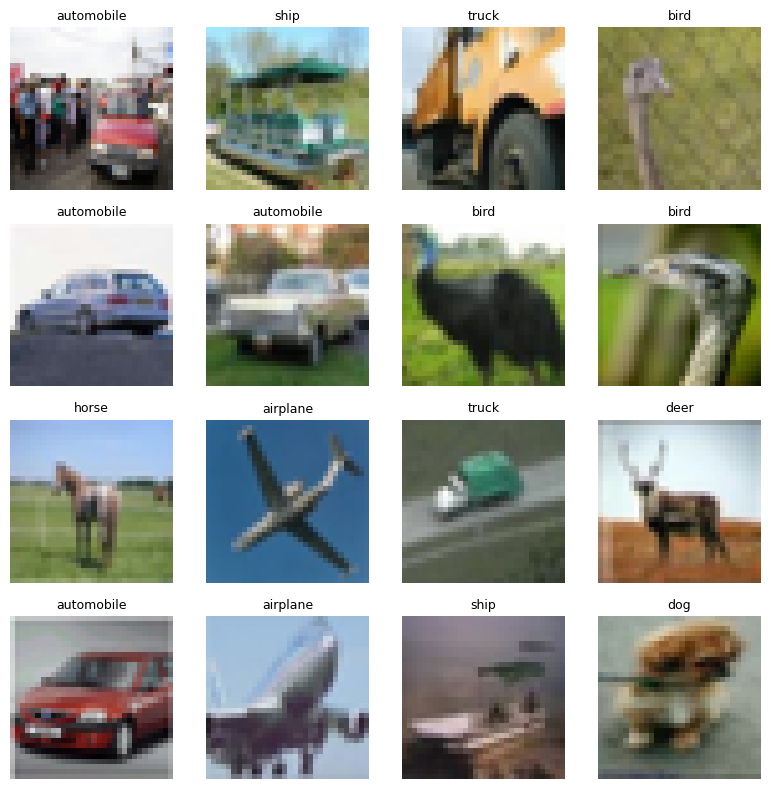

In [5]:

def unnormalize(img_tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    """Undo normalization for visualization."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor * std + mean

def show_grid(dataset, classes, n=16, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(int(np.sqrt(n)), int(np.sqrt(n)), figsize=(8, 8))
    axes = axes.flatten()

    for ax, idx in zip(axes, idxs):
        x, y = dataset[idx]
        x_vis = unnormalize(x).clamp(0, 1)
        ax.imshow(x_vis.permute(1, 2, 0))
        ax.set_title(classes[y], fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_grid(train_dataset, classes, n=16, seed=42)



## 4) DataLoaders

We will batch data and shuffle the training set.

**Tip:** using a larger batch size can improve GPU utilization.


In [6]:

# TODO: choose batch size (common values: 64, 128)
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check
x, y = next(iter(train_loader))
print("Batch images:", x.shape)  # expected: [B, 3, 32, 32]
print("Batch labels:", y.shape)  # expected: [B]


Batch images: torch.Size([128, 3, 32, 32])
Batch labels: torch.Size([128])



## 5) Build the CNN step by step

We’ll build the network in **parts**:

### Part A — a Conv Block
A common modern pattern is:

**Conv → BatchNorm → ReLU → (optional Pool)**

This block will be reused.


In [7]:

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, use_pool=True):
        super().__init__()

        # TODO: define convolution layer
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)

        # TODO: define batch normalization layer
        self.bn = torch.nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # Pooling reduces spatial resolution (e.g., 32x32 -> 16x16)
        self.pool = nn.MaxPool2d(2) if use_pool else nn.Identity()

    def forward(self, x):
        # TODO: apply conv -> bn -> relu -> pool
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x



### Part B — the Classifier Head

After convolution blocks, we typically **flatten** and use linear layers.

We will use:
- `Flatten`
- `Linear`
- `ReLU`
- `Dropout` (helps regularization)


In [8]:

class ClassifierHead(nn.Module):
    def __init__(self, in_features, num_classes=10, hidden=128, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()

        # TODO: define first linear layer (in_features -> hidden)
        self.fc1 = torch.nn.Linear(in_features, hidden)

        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)

        # TODO: define output linear layer (hidden -> num_classes)
        self.fc2 = torch.nn.Linear(hidden, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x



### Part C — full CNN model

We will stack two blocks:

- Block1: 3 → 32 channels + pooling
- Block2: 32 → 64 channels + pooling

Let’s compute the spatial shapes:
- Input: 3×32×32
- After Block1 pooling: 32×16×16
- After Block2 pooling: 64×8×8
- Flatten features: 64 * 8 * 8

We’ll use this value to build the classifier head.


In [9]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = ConvBlock(3, 32, kernel_size=3, padding=1, use_pool=True)
        self.block2 = ConvBlock(32, 64, kernel_size=3, padding=1, use_pool=True)

        # TODO: compute the number of features after conv blocks
        # Hint: for CIFAR-10 (32x32), after 2 pools you have 8x8 spatial size.
        in_features = 64 * 8 * 8

        self.head = ClassifierHead(in_features=in_features, num_classes=num_classes, hidden=128, dropout=0.2)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.head(x)
        return x

model = SimpleCNN(num_classes=10)

# TODO: move model to device (GPU/CPU)
model = model.to(device)

print(model)


SimpleCNN(
  (block1): ConvBlock(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ConvBlock(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): ClassifierHead(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=4096, out_features=128, bias=True)
    (relu): ReLU(inplace=True)
    (drop): Dropout(p=0.2, inplace=False)
    (fc2): Linear(in_features=128, out_features=10, bias=True)
  )
)



### Sanity check: forward pass shapes

We’ll run a forward pass on one batch.


In [10]:

model.eval()
x, y = next(iter(train_loader))

# TODO: move x to device
x = x.to(device)

with torch.no_grad():
    logits = model(x)

print("Input batch:", x.shape)
print("Logits:", logits.shape)  # expected: [B, 10]


Input batch: torch.Size([128, 3, 32, 32])
Logits: torch.Size([128, 10])



## 6) Loss and optimizer

For multi-class classification, we use:
- `CrossEntropyLoss` (expects raw logits)
- Optimizer: Adam (good default)


In [11]:

# TODO: define loss function
criterion = torch.nn.CrossEntropyLoss()

# TODO: define optimizer (Adam) with learning rate e.g. 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)


## 7) Training utilities

We will implement:
- accuracy computation
- one training epoch
- evaluation on test set

Common GPU :
- model on GPU but data still on CPU (or the opposite) → device mismatch error.


In [12]:

def accuracy_from_logits(logits, labels):
    """Compute accuracy from model outputs and integer labels."""
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for images, labels in loader:
        # TODO: move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # TODO: zero gradients
        optimizer.zero_grad()

        # TODO: forward pass
        logits = model(images)

        # TODO: compute loss
        loss = criterion(logits, labels)

        # TODO: backward pass
        loss.backward()

        # TODO: optimizer step
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, labels)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [15]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for images, labels in loader:
        # TODO: move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # TODO: forward pass
        logits = model(images)

        # TODO: compute loss
        loss = criterion(logits, labels)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, labels)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


## 8) Train the CNN

We’ll train for a few epochs (fast on GPU).

**Tip:** If training is slow, reduce epochs or batch size.


In [16]:

import time

# TODO: choose number of epochs (start with 3 to 5)
epochs = 20

history = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": []
}

for epoch in range(1, epochs + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch:02d} | "
          f"train loss={train_loss:.4f}, train acc={train_acc:.4f} | "
          f"test loss={test_loss:.4f}, test acc={test_acc:.4f} | "
          f"time={elapsed:.1f}s")


Epoch 01 | train loss=1.5230, train acc=0.4636 | test loss=1.3972, test acc=0.5202 | time=13.3s
Epoch 02 | train loss=1.3959, train acc=0.5090 | test loss=1.3044, test acc=0.5529 | time=13.8s
Epoch 03 | train loss=1.3044, train acc=0.5414 | test loss=1.2395, test acc=0.5709 | time=13.4s
Epoch 04 | train loss=1.2443, train acc=0.5640 | test loss=1.1896, test acc=0.5863 | time=13.6s
Epoch 05 | train loss=1.1936, train acc=0.5839 | test loss=1.1487, test acc=0.6032 | time=13.3s
Epoch 06 | train loss=1.1493, train acc=0.5991 | test loss=1.1167, test acc=0.6138 | time=13.3s
Epoch 07 | train loss=1.1093, train acc=0.6135 | test loss=1.0913, test acc=0.6195 | time=13.0s
Epoch 08 | train loss=1.0760, train acc=0.6274 | test loss=1.0642, test acc=0.6292 | time=13.3s
Epoch 09 | train loss=1.0439, train acc=0.6384 | test loss=1.0376, test acc=0.6394 | time=13.3s
Epoch 10 | train loss=1.0206, train acc=0.6489 | test loss=1.0212, test acc=0.6446 | time=13.3s
Epoch 11 | train loss=0.9993, train acc=


## 9) Plot training curves


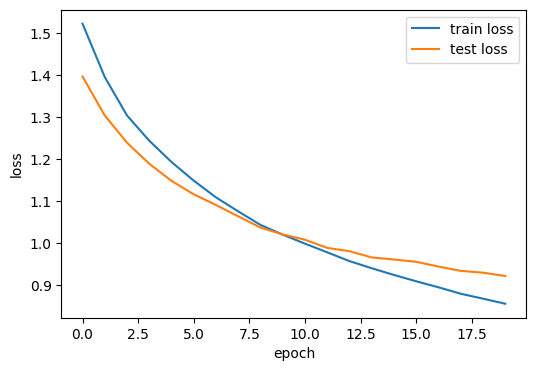

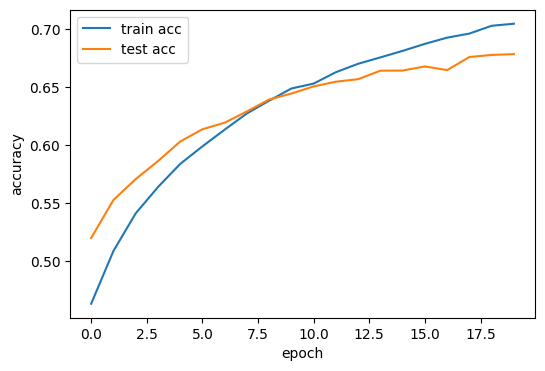

In [17]:

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["test_loss"], label="test loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["test_acc"], label="test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()



## 10) Inspect predictions

We’ll display a few test images and show:
- predicted label
- true label


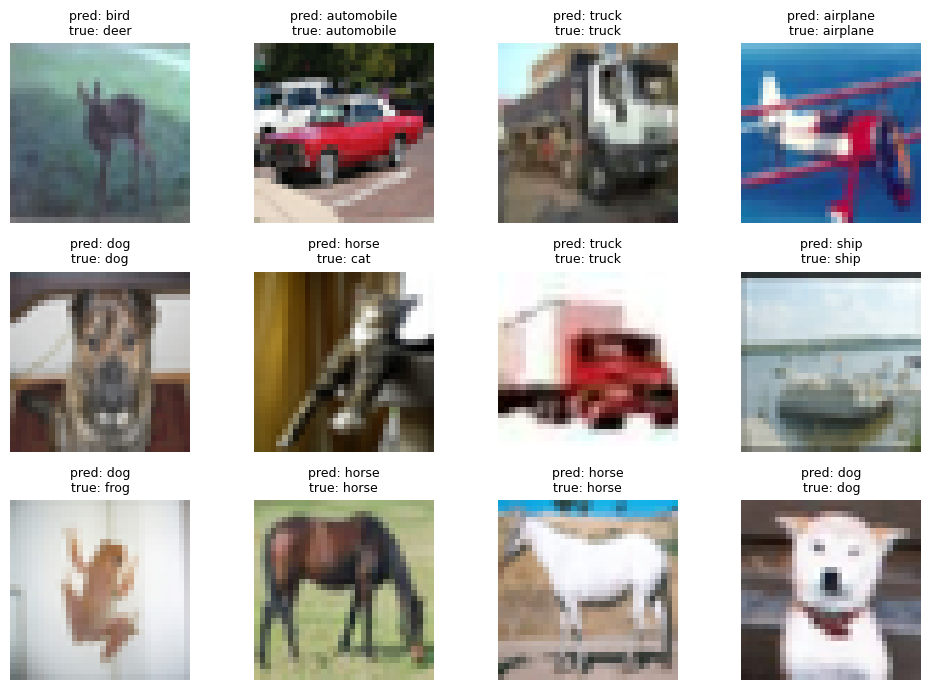

In [18]:

@torch.no_grad()
def show_predictions(model, dataset, classes, device, n=12, seed=123):
    model.eval()
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(10, 7))
    axes = axes.flatten()

    for ax, idx in zip(axes, idxs):
        x, y = dataset[idx]
        x_vis = unnormalize(x).clamp(0, 1)

        # TODO: add batch dimension and move to device
        xb = x.unsqueeze(0).to(device)

        logits = model(xb)
        pred = logits.argmax(dim=1).item()

        ax.imshow(x_vis.permute(1, 2, 0))
        ax.set_title(f"pred: {classes[pred]}\ntrue: {classes[y]}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, classes, device, n=12, seed=7)



## 11) Bonus

1. Add a **third ConvBlock** (64 → 128) and update `in_features` accordingly.
2. Replace MaxPool with **stride=2 convolution** and compare.
3. Try **SGD** instead of Adam (add momentum=0.9).
4. Add simple data augmentation to the training transforms:
   - RandomCrop(32, padding=4)
   - RandomHorizontalFlip()


### Visualizing CNN Stages on One Example Image, a  cat.


Train samples: 50000 | Test samples: 10000
SimpleCNN_v2(
  (block1): ConvBlock(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ConvBlock(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): ConvBlock(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (

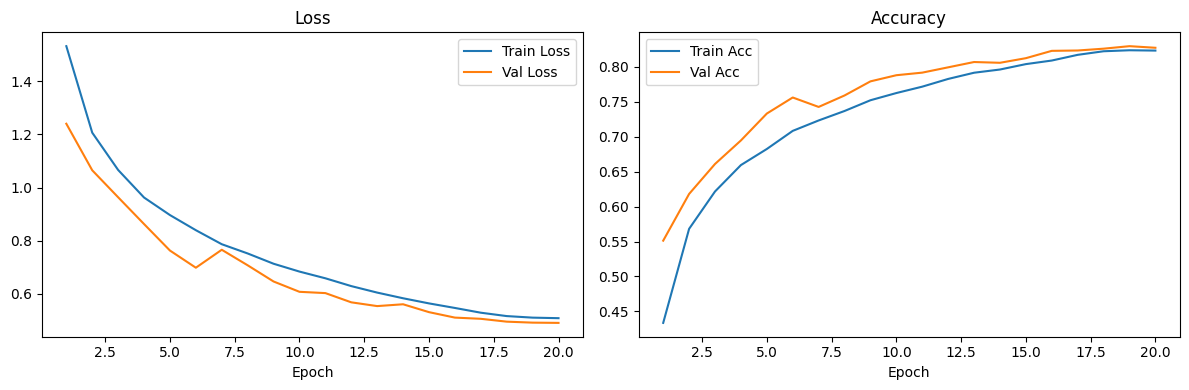

Training curves saved to training_curves.png


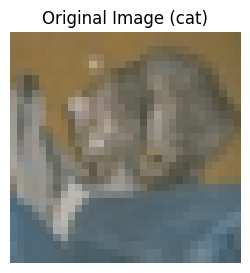

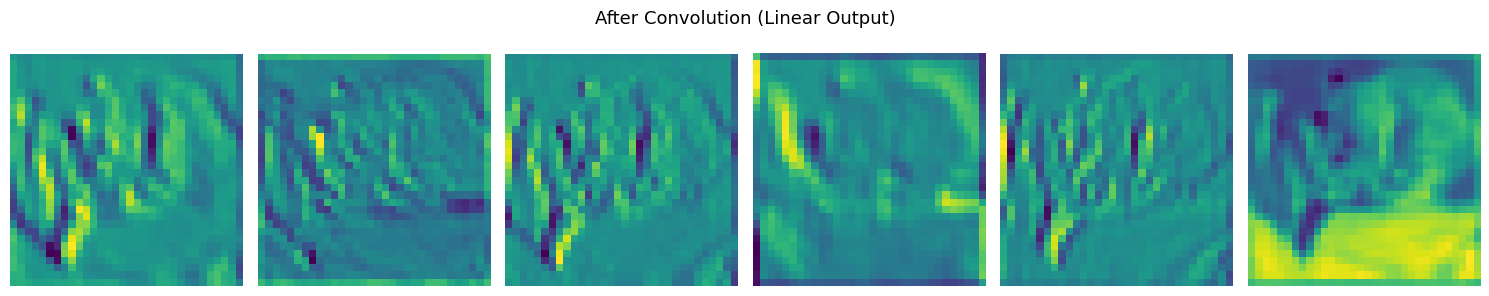

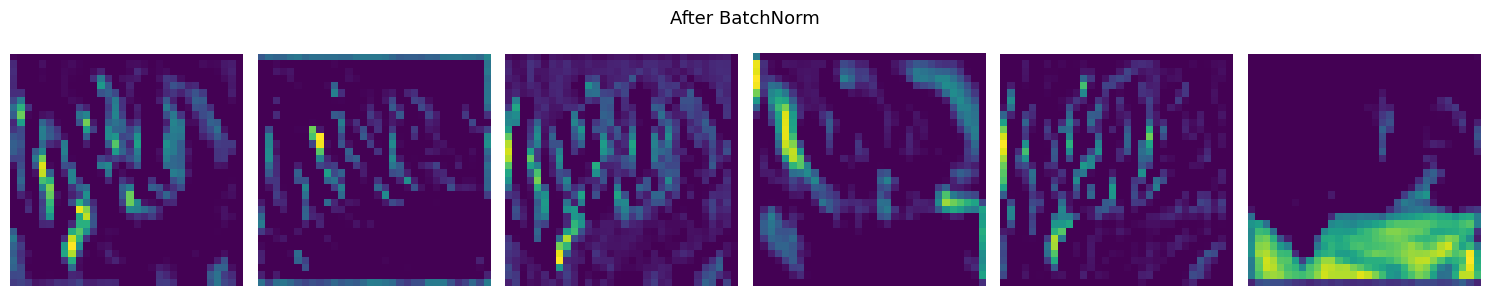

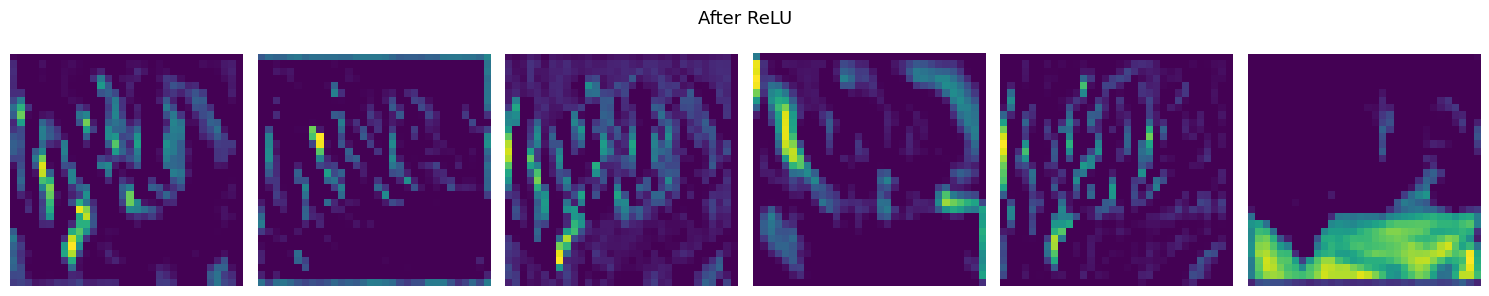

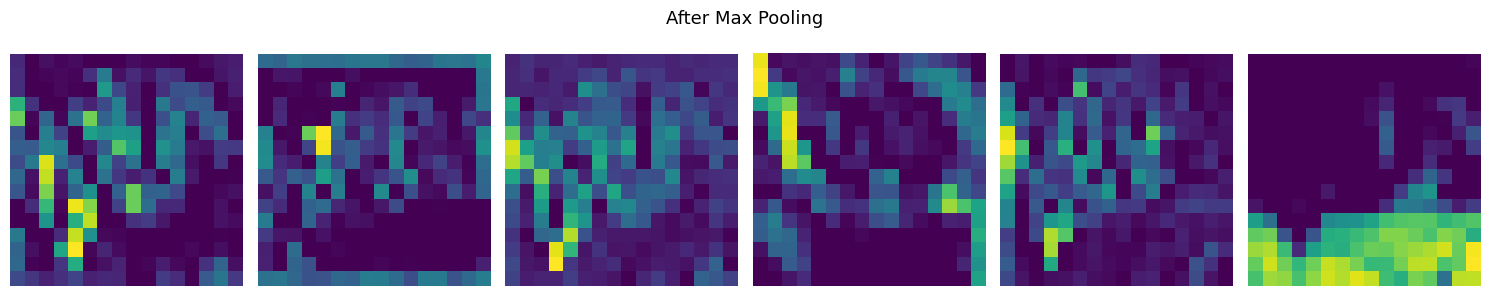


Per-class Accuracy:
------------------------------
     plane : 0.8480
       car : 0.9260
      bird : 0.7220
       cat : 0.6510
      deer : 0.8160
       dog : 0.7730
      frog : 0.8910
     horse : 0.8440
      ship : 0.9020
     truck : 0.9020


In [19]:
# 1. Data Augmentation & Transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


# 2. Reloading the datasets & DataLoaders
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=2
)

classes = (
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

# Modified model using maxpooling strid = 2

class ConvBlock(nn.Module):
    """
    Conv2d → BatchNorm2d → ReLU → Pool (MaxPool2d or stride-2 Conv)

    Args:
        use_pool     : True  → MaxPool2d(2, stride=2)  (default)
                       False → stride=2 on the Conv itself (learned downsampling)
    """
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        padding=1,
        use_pool=True,
    ):
        super().__init__()

        stride = 1 if use_pool else 2          # stride-2 conv when no pool

        self.conv = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            padding=padding,
            stride=stride,
        )
        self.bn   = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, stride=2) if use_pool else nn.Identity()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x


class ClassifierHead(nn.Module):
    """Flatten → Linear → ReLU → Dropout → Linear (logits)."""

    def __init__(self, in_features, num_classes=10, hidden=128, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1  = nn.Linear(in_features, hidden)
        self.relu = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(hidden, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x


# NEW Full CNN Model

class SimpleCNN_v2(nn.Module):
    def __init__(self, num_classes=10, use_pool=True):
        super().__init__()
        self.block1 = ConvBlock(3,   32,  kernel_size=3, padding=1, use_pool=use_pool)
        self.block2 = ConvBlock(32,  64,  kernel_size=3, padding=1, use_pool=use_pool)
        self.block3 = ConvBlock(64,  128, kernel_size=3, padding=1, use_pool=use_pool)

        # 3 downsampling steps: 32 → 16 → 8 → 4
        in_features = 128 * 4 * 4

        self.head = ClassifierHead(
            in_features=in_features,
            num_classes=num_classes,
            hidden=128,
            dropout=0.2,
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.head(x)
        return x


model = SimpleCNN_v2(num_classes=10, use_pool=True).to(device)
print(model)


# A sanity-check forward pass
model.eval()
x_sample, y_sample = next(iter(train_loader))
x_sample = x_sample.to(device)

with torch.no_grad():
    logits = model(x_sample)

print(f"\nInput batch : {x_sample.shape}")   # [B, 3, 32, 32]
print(f"Logits shape: {logits.shape}")       # [B, 10]


# Loss & Optimiser  (SGD + momentum)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4,
)

# Cosine annealing: smoothly decays LR to 0 over T_max epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20
)


# Training & Evaluation

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds    = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            running_loss += loss.item() * imgs.size(0)
            preds    = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)

    return running_loss / total, correct / total


# Training Loop
NUM_EPOCHS = 20

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}  {'LR':>8}")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, test_loader,  criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(
        f"{epoch:>6}  {train_loss:>10.4f}  {train_acc:>9.4f}"
        f"  {val_loss:>9.4f}  {val_acc:>8.4f}  {current_lr:>8.6f}"
    )

print("-"*60)
print(f"\nBest val accuracy: {max(history['val_acc']):.4f}")


#  Plots

epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train Loss")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train Acc")
axes[1].plot(epochs, history["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Training curves saved to training_curves.png")


# Feature-Map Visualisation (block1 stages)
model.eval()

img_vis_raw, label_vis = test_dataset[0]
img_vis = unnormalize(img_vis_raw).clamp(0, 1)
x_vis   = img_vis_raw.unsqueeze(0).to(device)

with torch.no_grad():
    conv_out = model.block1.conv(x_vis)          # after Conv2d
    bn_out   = model.block1.bn(conv_out)         # after BatchNorm
    relu_out = model.block1.relu(bn_out)         # after ReLU
    pool_out = model.block1.pool(relu_out)       # after Pool

# Move to CPU for plotting
conv_out = conv_out.cpu()
bn_out   = bn_out.cpu()
relu_out = relu_out.cpu()
pool_out = pool_out.cpu()


def plot_feature_maps(tensor, title, max_maps=6):
    """tensor shape: [1, C, H, W]"""
    feature_maps = tensor[0]
    n_maps = min(feature_maps.shape[0], max_maps)

    fig, axes = plt.subplots(1, n_maps, figsize=(15, 3))
    fig.suptitle(title, fontsize=13)
    for i in range(n_maps):
        axes[i].imshow(feature_maps[i], cmap="viridis")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


# Original image
plt.figure(figsize=(3, 3))
plt.imshow(img_vis.permute(1, 2, 0))
plt.title(f"Original Image ({classes[label_vis]})")
plt.axis("off")
plt.show()

plot_feature_maps(conv_out, "After Convolution (Linear Output)")
plot_feature_maps(bn_out,   "After BatchNorm")
plot_feature_maps(relu_out, "After ReLU")
plot_feature_maps(pool_out, "After Max Pooling")


# Per-class Accuracy

model.eval()
class_correct = [0] * 10
class_total   = [0] * 10

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        for c in range(10):
            mask = labels == c
            class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            class_total[c]   += mask.sum().item()

print("\nPer-class Accuracy:")
print("-" * 30)
for c in range(10):
    acc = class_correct[c] / class_total[c]
    print(f"  {classes[c]:>8s} : {acc:.4f}")